# 1. Importando dados

In [431]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import my_module as my

sns.set_style('darkgrid')

In [432]:
df = pd.read_csv('data/dados.csv', index_col='Data')
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
30.06.2025,138.855,136.865,139.103,136.430,"7,68M","1,45%"
27.06.2025,136.866,137.113,137.209,136.469,"6,24B","-0,18%"
26.06.2025,137.114,135.767,137.353,135.756,"8,02B","0,99%"
25.06.2025,135.767,137.163,137.163,135.565,"7,71B","-1,02%"
24.06.2025,137.165,136.552,138.156,136.254,"8,08B","0,45%"


## Tratamento e formatação

In [433]:
col_dict = my.format_columns(df)

# Formatacao e nomeacao do index
df.index = pd.to_datetime(df.index, dayfirst=True)
df.index = df.index.rename('data')
col_dict ['data'] = 'Data'

# Ordenando nosso index
df = df.sort_index()

# Tornando 'var' em numero
df['var'] = df['var'].replace('%','',regex=True).replace(',','.',regex=True)
df['var'] = df['var'].astype(float)/100

df.head()

,ultimo,abertura,maxima,minima,vol,var
data,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,"1,82M",-0.0028
2010-02-01,66.572,65.402,66.763,65.362,"1,49M",0.0179
2010-02-02,67.163,66.589,67.321,66.539,"1,59M",0.0089
2010-02-03,67.109,67.163,67.347,66.774,"1,76M",-0.0008
2010-02-04,63.934,67.100,67.100,63.750,"2,26M",-0.0473


In [434]:
df['vol'] = df['vol'].replace(',','.',regex=True)

df = df.dropna()

In [435]:
# Transformando volume em número
new_col = 'volume'
df[new_col] = 0

mask_million = df['vol'].str.contains('M')
df.loc[mask_million, new_col] = df.loc[mask_million, 'vol'].replace('M','',regex=True).astype(float)*1_000_000

mask_billion = df['vol'].str.contains('B')
df.loc[mask_billion, new_col] = df.loc[mask_billion, 'vol'].replace('B','',regex=True).astype(float)*1_000_000_000

mask_thousand = df['vol'].str.contains('K')
df.loc[mask_thousand, new_col] = df.loc[mask_thousand, 'vol'].replace('K','',regex=True).astype(float)*1_000

df = df.drop('vol', axis=1)

df['const'] = 1

df

D:\Temp\ipykernel_37288\2831821053.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1820000. 1490000. 1590000. ... 9800000. 9690000. 7680000.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask_million, new_col] = df.loc[mask_million, 'vol'].replace('M','',regex=True).astype(float)*1_000_000


,ultimo,abertura,maxima,minima,var,volume,const
data,,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,-0.0028,1.820000e+06,1
2010-02-01,66.572,65.402,66.763,65.362,0.0179,1.490000e+06,1
2010-02-02,67.163,66.589,67.321,66.539,0.0089,1.590000e+06,1
2010-02-03,67.109,67.163,67.347,66.774,-0.0008,1.760000e+06,1
2010-02-04,63.934,67.100,67.100,63.750,-0.0473,2.260000e+06,1
...,...,...,...,...,...,...,...
2025-06-24,137.165,136.552,138.156,136.254,0.0045,8.080000e+09,1
2025-06-25,135.767,137.163,137.163,135.565,-0.0102,7.710000e+09,1
2025-06-26,137.114,135.767,137.353,135.756,0.0099,8.020000e+09,1


In [436]:
# Fazendo uma dataframe contínua, que incue os dias não úteis

df_cont = df.copy(True).asfreq('d')
df_cont = df_cont.fillna('0')[:-1]

df_cont['const'] = 1

df_cont.head()

,ultimo,abertura,maxima,minima,var,volume,const
data,,,,,,,
2010-01-29,65.402,65.591,66.576,65.14,-0.0028,1820000.0,1
2010-01-30,0,0,0,0,0,0,1
2010-01-31,0,0,0,0,0,0,1
2010-02-01,66.572,65.402,66.763,65.362,0.0179,1490000.0,1
2010-02-02,67.163,66.589,67.321,66.539,0.0089,1590000.0,1


In [437]:
for c in df_cont.columns:
    df_cont[c] = df_cont[c].astype(float)
df_cont

,ultimo,abertura,maxima,minima,var,volume,const
data,,,,,,,
2010-01-29,65.402,65.591,66.576,65.140,-0.0028,1.820000e+06,1.0
2010-01-30,0.000,0.000,0.000,0.000,0.0000,0.000000e+00,1.0
2010-01-31,0.000,0.000,0.000,0.000,0.0000,0.000000e+00,1.0
2010-02-01,66.572,65.402,66.763,65.362,0.0179,1.490000e+06,1.0
2010-02-02,67.163,66.589,67.321,66.539,0.0089,1.590000e+06,1.0
...,...,...,...,...,...,...,...
2025-06-25,135.767,137.163,137.163,135.565,-0.0102,7.710000e+09,1.0
2025-06-26,137.114,135.767,137.353,135.756,0.0099,8.020000e+09,1.0
2025-06-27,136.866,137.113,137.209,136.469,-0.0018,6.240000e+09,1.0


### Configurações

In [438]:
## SETUP

cutoff_dates = True # Should you use a slice of the dataframe, instead of all of it?
cutoff = '2021-01-01' # Where should the slice start?
if cutoff_dates:
    mask = df.index > cutoff

    df = df[mask]

n_predictions = 30 # How many days should be predicted?


### Fazendo targets

In [439]:
# Targets
def make_var_columns(df):
    '''
    Makes the columns: var_class, var_amanha, var_amanha class
    '''
    df['var_class'] = [1 if df.iloc[i]['var'] > 0 or df.iloc[i]['var'] == np.nan else 0 for i in range(len(df))]
    col_dict['var_class'] = 'Dia é crescente'
    df['var_amanha'] = df['var'].shift(-1)
    col_dict['var_amanha'] = 'Variação do dia seguinte'
    df['var_amanha_class'] = df['var_class'].shift(-1)
    col_dict['var_amanha_class'] = 'Dia seguinte será crescente?'

In [440]:
# More Parameters
def make_week_columns(df):
    '''
    Makes the columns: dia_semana, dia_util, dia_util_anterior
    '''
    df['dia_semana'] = df.index.weekday
    col_dict['dia_semana'] = 'Dia da semana'
    df['dia_util'] = [1 if df.iloc[i]['volume'] > 0 or df.iloc[i]['volume'] == np.nan else 0 for i in range(len(df))]
    col_dict['dia_util'] = 'Dia é útil'
    df['dia_util_anterior'] = df['dia_util'].shift(1)
    col_dict['dia_util_anterior'] = 'Dia anterior é útil'

In [441]:
make_var_columns(df)
make_week_columns(df)

df = df.dropna()

df.head()

D:\Temp\ipykernel_37288\3098085235.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['var_class'] = [1 if df.iloc[i]['var'] > 0 or df.iloc[i]['var'] == np.nan else 0 for i in range(len(df))]
D:\Temp\ipykernel_37288\3098085235.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['var_amanha'] = df['var'].shift(-1)
D:\Temp\ipykernel_37288\3098085235.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


,ultimo,abertura,maxima,minima,var,volume,const,var_class,var_amanha,var_amanha_class,dia_semana,dia_util,dia_util_anterior
data,,,,,,,,,,,,,
2021-01-05,119.376,118.835,119.790,116.756,0.0044,9260000.0,1,1,-0.0023,0.0,1,1,1.0
2021-01-06,119.100,119.377,120.924,118.917,-0.0023,11640000.0,1,0,0.0276,1.0,2,1,1.0
2021-01-07,122.386,119.103,122.697,119.101,0.0276,11770000.0,1,1,0.0220,1.0,3,1,1.0
2021-01-08,125.077,122.387,125.324,122.386,0.0220,11090000.0,1,1,-0.0146,0.0,4,1,1.0
2021-01-11,123.255,125.075,125.075,122.506,-0.0146,9540000.0,1,0,0.0060,1.0,0,1,1.0


In [442]:
make_var_columns(df_cont)
make_week_columns(df_cont)

df_cont = df_cont.dropna()

df_cont.shape

(5629, 13)

In [443]:
x_parameters = list(df.columns)

for r in [
    'var_amanha', 
    'var_amanha_class',
    'var_class'
    ]:
    x_parameters.remove(r)

x_parameters

['ultimo',
 'abertura',
 'maxima',
 'minima',
 'var',
 'volume',
 'const',
 'dia_semana',
 'dia_util',
 'dia_util_anterior']

### Escalonamento

In [444]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_cont = StandardScaler()
scaler_cont.set_output(transform="pandas")

scaler_cont.fit(
    df_cont
)

scaler_cont

,copy,True
,with_mean,True
,with_std,True


In [445]:
def reverse_scaler(
        scaler : StandardScaler | MinMaxScaler,
        scaled_data : pd.DataFrame | pd.Series,
        round_to : int = 5
):
    new_series = np.round(scaler.inverse_transform(scaled_data), round_to)
    
    if type(scaled_data) == type(pd.DataFrame()):
        new_df = pd.DataFrame(new_series,
                                columns = scaled_data.columns,
                                index = scaled_data.index)
        return new_df
    else:
        return new_series

In [446]:
df_cont_scaled = scaler_cont.transform(df_cont)
df_cont_scaled.head()

,ultimo,abertura,maxima,minima,var,volume,const,var_class,var_amanha,var_amanha_class,dia_semana,dia_util,dia_util_anterior
data,,,,,,,,,,,,,
2010-01-30,-1.242787,-1.242860,-1.244029,-1.241607,-0.017005,-0.144794,0.0,-0.729178,-0.017005,-0.729178,0.999822,-1.451974,0.688437
2010-01-31,-1.242787,-1.242860,-1.244029,-1.241607,-0.017005,-0.144794,0.0,-0.729178,1.459850,1.371407,1.499822,-1.451974,-1.452565
2010-02-01,0.231547,0.205963,0.223188,0.217720,1.459850,-0.143834,0.0,1.371407,0.717297,1.371407,-1.500178,0.688718,-1.452565
2010-02-02,0.244636,0.232258,0.235451,0.243999,0.717297,-0.143770,0.0,1.371407,-0.083010,-0.729178,-1.000178,0.688718,0.688437
2010-02-03,0.243440,0.244974,0.236023,0.249245,-0.083010,-0.143660,0.0,-0.729178,-3.919533,-0.729178,-0.500178,0.688718,0.688437


## Plotando

In [447]:
def set_ax_title(
        ax,
        title : str,
        fontsize = 20,
        loc = 'left'
):
    ax.set_title(f'{title}',
             fontsize = fontsize,
             loc = loc)


def export_fig(
        fig,
        file_name,
        tight = True
):
    if tight:
        plt.tight_layout()
    fig.savefig(f'plots/{file_name}.png')

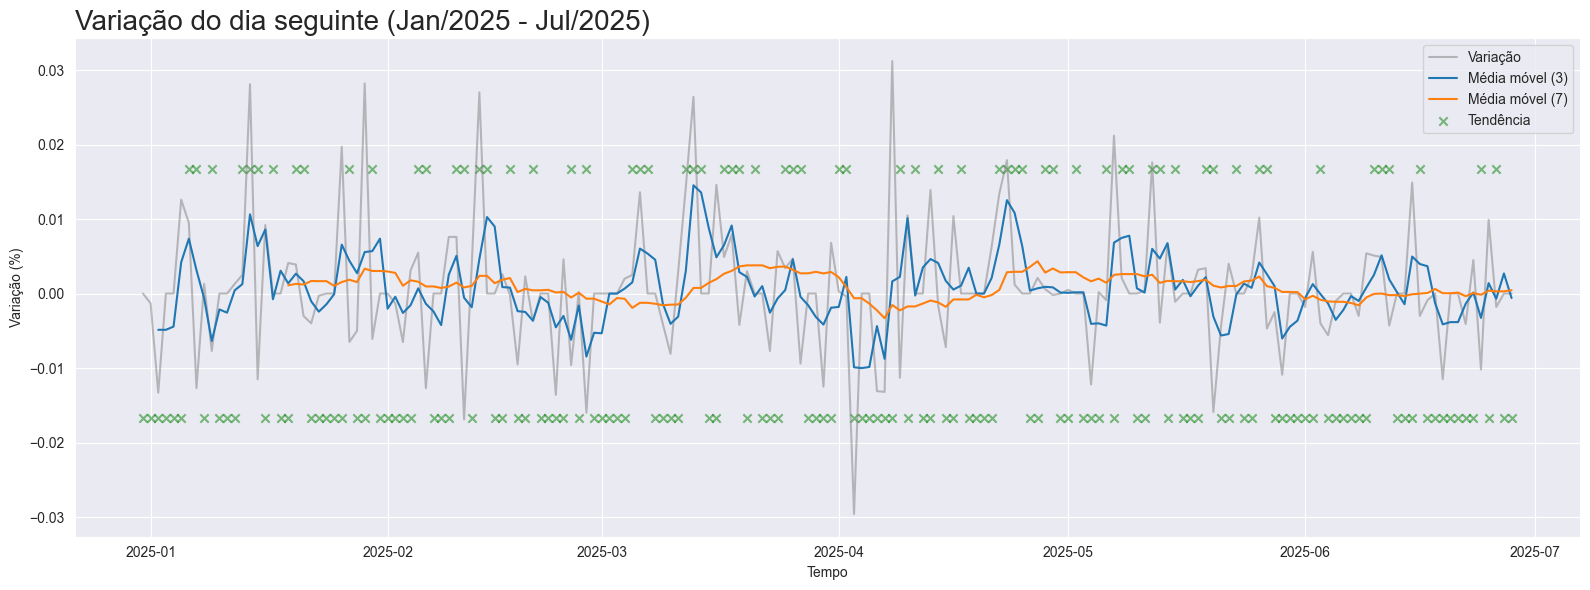

In [448]:
fig = plt.figure(figsize=(16, 6))

ax = plt.subplot()

to_plot = 'var_amanha'

period = -30*6

ax.plot(
    df_cont[period:][to_plot],
    label = 'Variação',
    color='gray',
    alpha = 0.5
)

ax.plot(
    df_cont[period:][to_plot].rolling(3).mean(),
    label = 'Média móvel (3)'
)

ax.plot(
    df_cont[period:][to_plot].rolling(20).mean(),
    label = 'Média móvel (7)'
)

# ax.plot(
#     df[period:][to_plot].rolling(3).std(),
#     label = 'std3'
# )

ax.scatter(
    df_cont[period:].index,
    (df_cont[period:]['var_class'] - 0.5)/30,
    color = 'g',
    marker = 'x',
    alpha = 0.5,
    label = 'Tendência'
)

ax.set_xlabel('Tempo')
ax.set_ylabel('Variação (%)')

ax.legend()

set_ax_title(
    ax,
    title = 'Variação do dia seguinte (Jan/2025 - Jul/2025)',
)


export_fig(fig = fig,
           file_name='lineplot_basic',
           tight = True)

In [449]:
from statsmodels.tsa.seasonal import seasonal_decompose

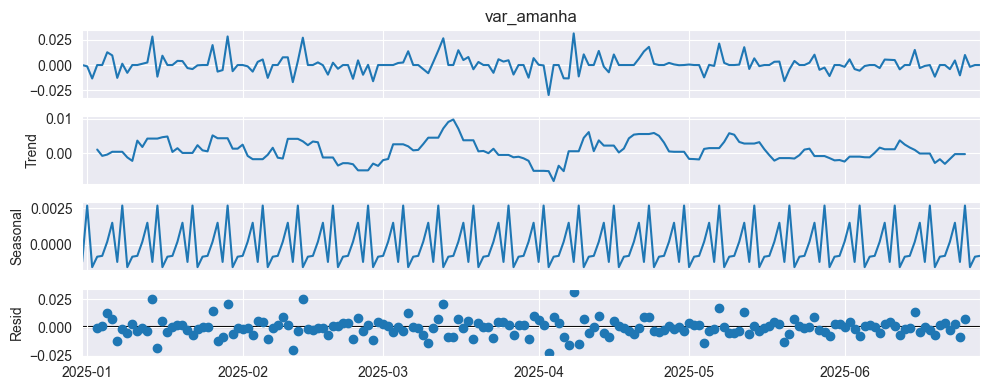

In [450]:
fig = seasonal_decompose(
    df_cont['var_amanha'][period:]
).plot()

fig.set_size_inches(10, 4)

ax = plt.gca()

# set_ax_title(
#     ax,
#     title = 'Decomposição sazonal da variação ()'
# )

export_fig(
    fig,
    'seasonal_decompose',
)

In [451]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

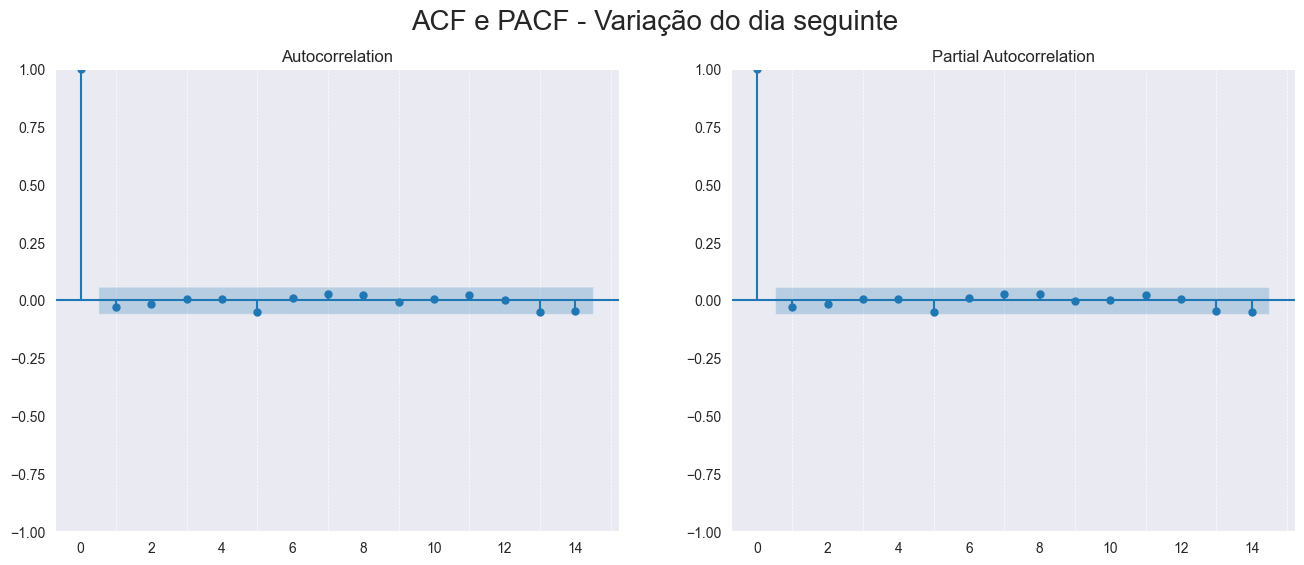

<Figure size 640x480 with 0 Axes>

In [452]:
lags = 14

to_plot = 'var_amanha'

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[to_plot]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()

export_fig(
    fig,
    'acf_pacf',
)


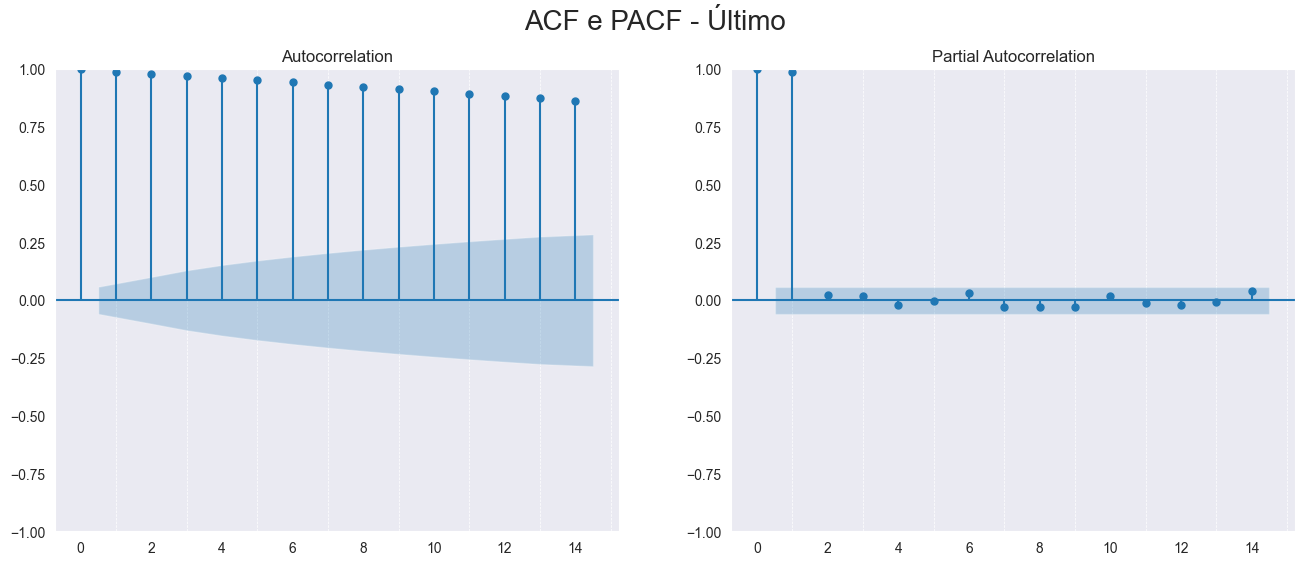

<Figure size 640x480 with 0 Axes>

In [454]:
lags = 14

to_plot = 'ultimo'

fig, axs = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (16, 6)
)

fig.suptitle(
    f'ACF e PACF - {col_dict[to_plot]}',
    fontsize = 20
)

ax = axs[0]
plot_acf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

ax = axs[1]
plot_pacf(
    df[to_plot],
    ax = ax,
    lags = lags
)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1,1))
ax.set_axisbelow(True)
ax.grid(
    which = 'major'
)
ax.grid(
    which = 'minor',
    linestyle = '--',
    linewidth = 0.5
)

plt.show()

export_fig(
    fig,
    'fechamento_acf_pacf',
)


***
# 2. Construindo modelo

## Pre-processing

In [286]:
from sklearn.model_selection import KFold, TimeSeriesSplit

SEED = 152
np.random.seed(SEED)

kf_params = {
    'splits': 10,
    'shuffle': True,
    'random_state': SEED
}

kf = KFold(
    n_splits = kf_params['splits'],
    shuffle = kf_params['shuffle'],
    random_state = kf_params['random_state']
)

kft = TimeSeriesSplit(
    n_splits = kf_params['splits'],
    test_size=30
)

In [287]:
def make_test_train(
        df,
        target,
        parameters,
        n_predictions):
    
    y = df[target]
    X = df[parameters]

    X_train = X.iloc[: - n_predictions]
    y_train = y.iloc[: - n_predictions]

    X_test = X.iloc[- n_predictions:]
    y_test = y.iloc[- n_predictions:]

    return X_train, y_train, X_test, y_test, X, y

X_train, y_train, X_test, y_test, X, y = make_test_train(
    df,
    target = 'var_amanha',
    parameters = x_parameters,
    n_predictions = n_predictions
)

y_test.shape

(30,)

In [288]:
X_cont_train, y_cont_train, X_cont_test, y_cont_test, X_cont, y_cont = make_test_train(
    df_cont,
    target = 'var_amanha',
    parameters = x_parameters,
    n_predictions = n_predictions
)

y_cont_test.shape

(30,)

In [289]:
X_cont_train_scaled, y_cont_train_scaled, X_cont_test_scaled, y_cont_test_scaled, X_cont_scaled, y_cont_scaled = make_test_train(
    df_cont_scaled,
    target = 'var_amanha',
    parameters = x_parameters,
    n_predictions = n_predictions
)

y_cont_test_scaled.shape

(30,)

In [290]:
import datetime

start_predictions = y_train.index[-1] + datetime.timedelta(days=1)
end_predictions = start_predictions + datetime.timedelta(days=n_predictions)

start_predictions, end_predictions

(Timestamp('2025-05-16 00:00:00'), Timestamp('2025-06-15 00:00:00'))

## Time-Series models

In [343]:
y_target = 'var_amanha'

In [344]:
def plot_prediction(
        y_pred,
        y_true,
        y_train,
        train_include : int = 60,
        bar = True
):
    fig = plt.figure(figsize = (20,6))
    ax = plt.subplot()


    if bar:
        ax.bar(
            x = y_pred.index,
            height = y_pred,
            color = 'r',
            label = 'Predicted'
            )
        
        ax.bar(
            x = y_true.index,
            height = y_true,
            color = 'g',
            alpha = 0.5,
            label = 'Expected'
        )

        ax.bar(
            x = y_train.iloc[-train_include:].index,
            height = y_train.iloc[-train_include:],
            color = 'gray',
            alpha = 0.5,
            label = 'Training data'
        )
    else:
        ax.plot(
            y_pred,
            color = 'r',
            label = 'Predicted'
            )
        
        ax.plot(
            y_true,
            color = 'g',
            label = 'Expected'
        )

        ax.plot(
            y_train.iloc[-train_include:],
            color = 'gray',
            alpha = 0.5,
            label = 'Training data'
        )

    # ax.legend()

    # # ax.set_title(f'{col_dict[y_col]}')

    ax.grid()

    return fig, ax

In [345]:
def make_class(
        y_pred,
        y_true
):
    df_pred = pd.DataFrame({
    'var_amanha':y_pred,
    'var_amanha_class':[1 if y_pred.iloc[i] > 0 or
                        y_pred.iloc[i] == np.nan 
                        else 0 for i in range(len(y_pred))]
    })
    
    
    df_true = pd.DataFrame({
    'var_amanha':y_true,
    'var_amanha_class':[1 if y_true.iloc[i] > 0 or
                        y_true.iloc[i] == np.nan 
                        else 0 for i in range(len(y_true))]
    })

    return df_pred, df_true

In [346]:
def make_y_dfs(
                y_pred : pd.Series,
                y_true : pd.Series,
                ):
        '''
        From continuous series, makes dfs with 'var_amanha' (the original y_pred) and 'var_amanha_class' as columns.
        '''
        df_pred, df_true = make_class(
                y_pred = y_pred,
                y_true = y_true)
        
        return df_pred, df_true


In [347]:
def get_class_metrics(
        df_pred : pd.DataFrame,
        df_true : pd.DataFrame,
        y_class_col = 'var_amanha_class'
):
        '''
        From dataframe with 'var_amanha_class', returns the classification metrics.
        '''
        acc = accuracy_score(
                y_true = df_true[y_class_col],
                y_pred = df_pred[y_class_col]
        )

        prec = precision_score(
                y_true = df_true[y_class_col],
                y_pred = df_pred[y_class_col]
        )

        rec = recall_score(
                y_true = df_true[y_class_col],
                y_pred = df_pred[y_class_col]
        )

        return acc, prec, rec

In [348]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def make_confusion_matrix(
        y_true,
        y_pred,
        model = ''
):
        cm = confusion_matrix(
        y_true = y_true,
        y_pred = y_pred
        )

        fig, ax = plt.subplots(figsize=(5,5))

        disp = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels = ['Baixa', 'Alta']
        )

        disp.plot(ax = ax)
        ax.set_title(f'Confusion Matrix | {model}')
        ax.grid(False)

        return fig, ax

In [349]:
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, roc_auc_score

def plot_and_get_metrics(
        y_pred : pd.Series,
        y_true : pd.Series,
        y_train : pd.Series,
        model : str = '',
        y_class_col = 'var_amanha_class',
        train_include : int = 60
):
        '''
        Gets continuous values and checks their accuracy as class values.

        Arguments
        *********
        y_pred (pd.Series)
                Predicted continuous values
        y_true (pd.Series)
                Real continuous values
        y_train (pd.Series)
                Historical continuous values
        model (str)
                Name of the model for graph titles
        y_class_col (str)
                Name of the created class column
        train_include (int)
                Amount of train data to include in the graph (default 60)

        Returns
        *******
        fig1, fig2
                The prediction plot, and the confusion matrix plot
        '''
        
        df_pred, df_true = make_y_dfs(y_pred=y_pred, y_true=y_true)

        acc, prec, rec = get_class_metrics(df_pred = df_pred, df_true = df_true)

        print(f'ACC = {acc:.4f} | PREC = {prec:.4f} | REC = {rec:.4f}')
        
        fig1, ax = plot_prediction(y_pred, y_true, y_train, train_include)

        ax.hlines(
                y = 0,
                xmin = y_train.iloc[-train_include:].index[0],
                xmax = y_pred.index[-1],
                color = 'black',
                alpha = 0.5
        )

        ax.scatter(
                df_pred.index,
                (df_pred[y_class_col] - 0.5)/20,
                color = 'r',
                label = 'Predicted direction',
                alpha = 0.5)
        
        
        ax.scatter(
                df_true.index,
                (df_true[y_class_col] - 0.5)/20,
                color = 'g',
                label = 'Real direction',
                marker = 'x',
                alpha = 0.5)
        
        ax.legend()

        ax.set_title(f'Predição: {col_dict[y_class_col]} | {model}', fontsize = 20, loc='left')

        ax.grid()

        fig2, ax = make_confusion_matrix(
                y_true = df_true[y_class_col],
                y_pred=df_pred[y_class_col],
                model = model
        )

        return fig1, fig2
        

### ARIMA

#### Raw Values

ACC = 0.8000 | PREC = 0.5714 | REC = 0.5714


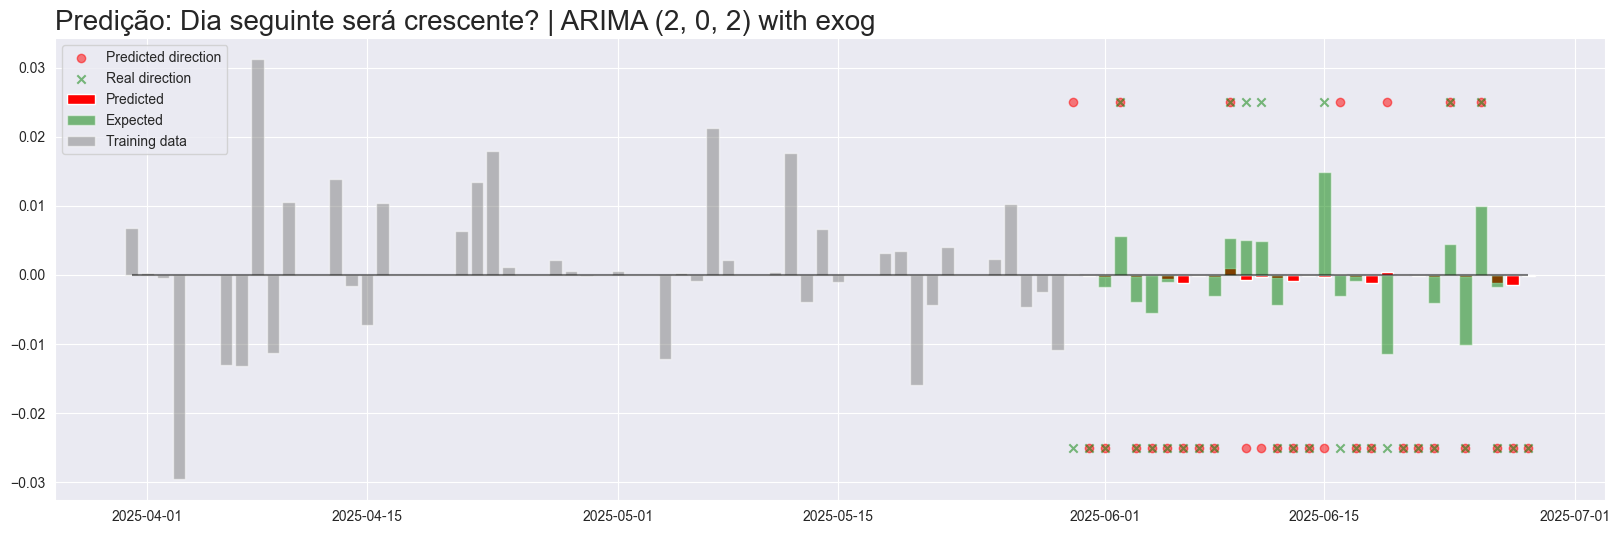

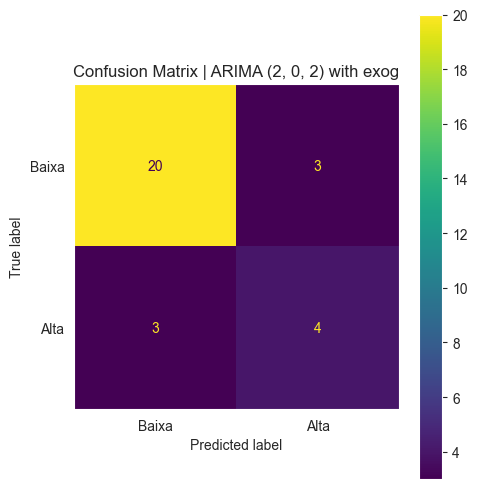

In [324]:
from statsmodels.tsa.arima.model import ARIMA
exog_cols = ['abertura', 'maxima', 'minima', 'dia_semana']

model = ARIMA(
    endog = y_cont_train,
    exog = X_cont_train[exog_cols],
    order = (2, 0, 2)
).fit()

y_pred = model.forecast(
    steps = n_predictions,
    exog = X_cont_test[exog_cols]
)

fig1, fig2 = plot_and_get_metrics(
    y_pred,
    y_cont_test,
    y_cont_train,
    model = 'ARIMA (2, 0, 2) with exog'
)

export_fig(
    fig1,
    'pred_arima202',
    True
)

export_fig(
    fig2,
    'pred_arima202_cm'
)

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ACC = 0.7333 | PREC = 0.4286 | REC = 0.4286


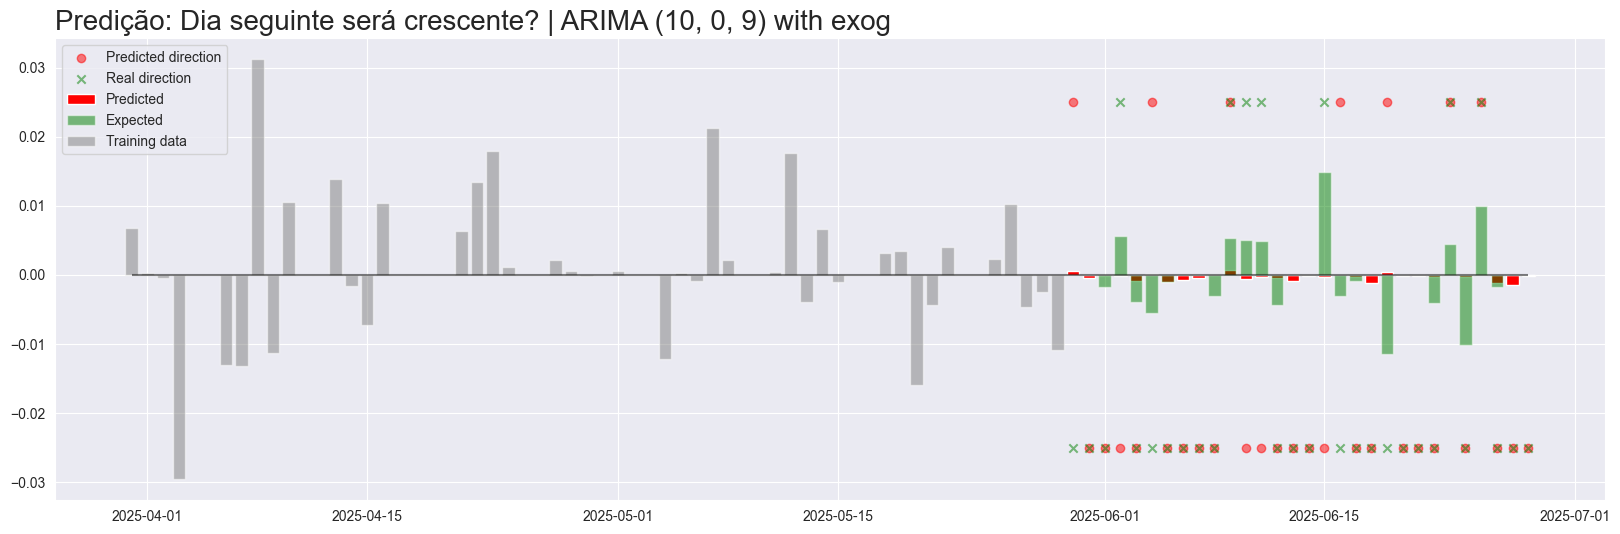

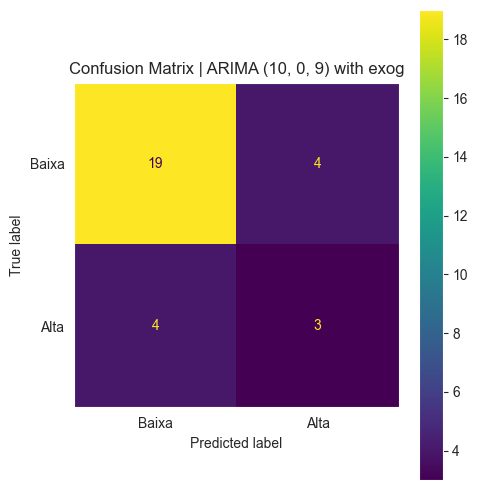

In [325]:
from statsmodels.tsa.arima.model import ARIMA
exog_cols = ['abertura', 'maxima', 'minima', 'dia_semana']

model = ARIMA(
    endog = y_cont_train,
    exog = X_cont_train[exog_cols],
    order = (10, 0, 9)
).fit()

y_pred = model.forecast(
    steps = n_predictions,
    exog = X_cont_test[exog_cols]
)

fig1, fig2 = plot_and_get_metrics(
    y_pred,
    y_cont_test,
    y_cont_train,
    model = 'ARIMA (10, 0, 9) with exog'
)

export_fig(
    fig1,
    'pred_arima1009',
    True
)

export_fig(
    fig2,
    'pred_arima1009_cm'
)

#### Scaled Values

ACC = 0.8000 | PREC = 0.5714 | REC = 0.5714


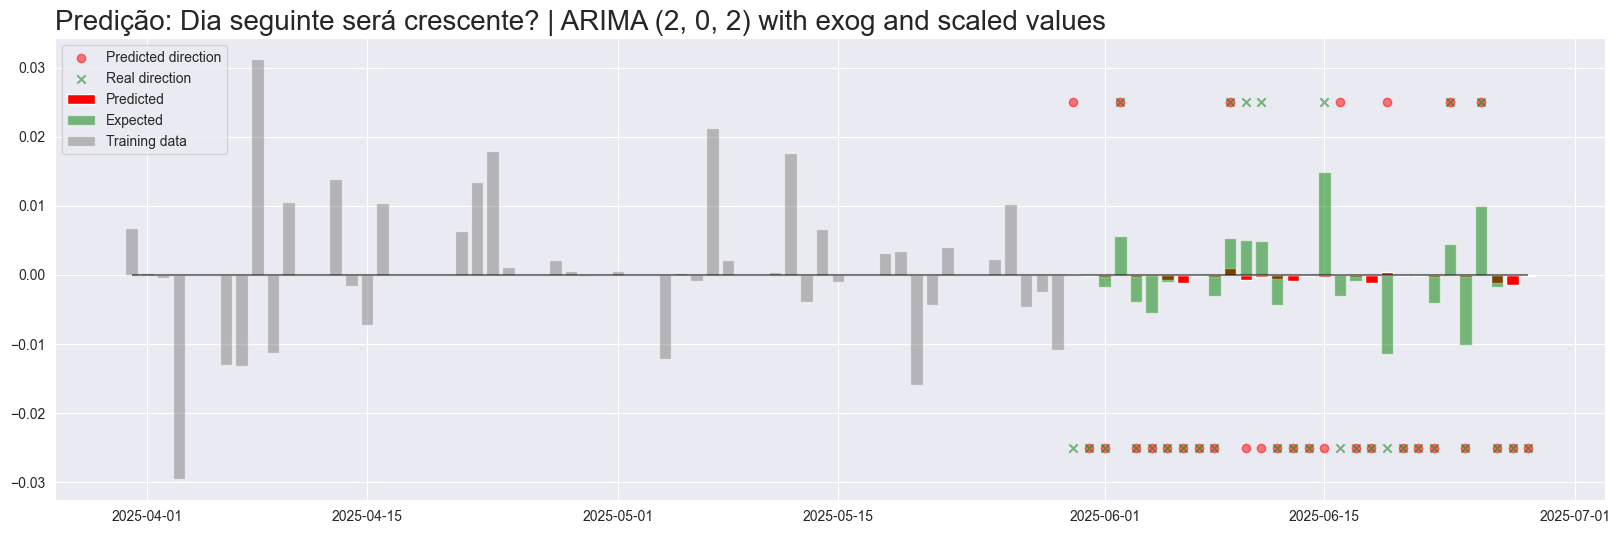

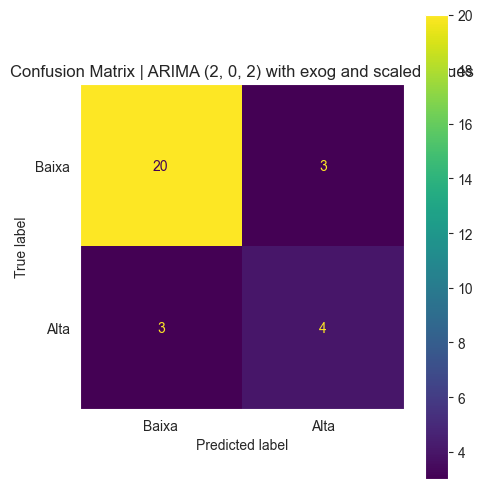

In [326]:
exog_cols = ['abertura', 'maxima', 'minima', 'dia_semana']

model = ARIMA(
    endog = y_cont_train,
    exog = X_cont_train_scaled[exog_cols],
    order = (2, 0, 2)
).fit()

y_pred = model.forecast(
    steps = n_predictions,
    exog = X_cont_test_scaled[exog_cols]
)

fig1, fig2 = plot_and_get_metrics(
    y_pred,
    y_cont_test,
    y_cont_train,
    model = 'ARIMA (2, 0, 2) with exog and scaled values'
)

export_fig(
    fig1,
    'pred_scaled_arima202',
    True
)

export_fig(
    fig2,
    'pred_scaled_arima202_cm'
)

ACC = 0.6667 | PREC = 0.2857 | REC = 0.2857


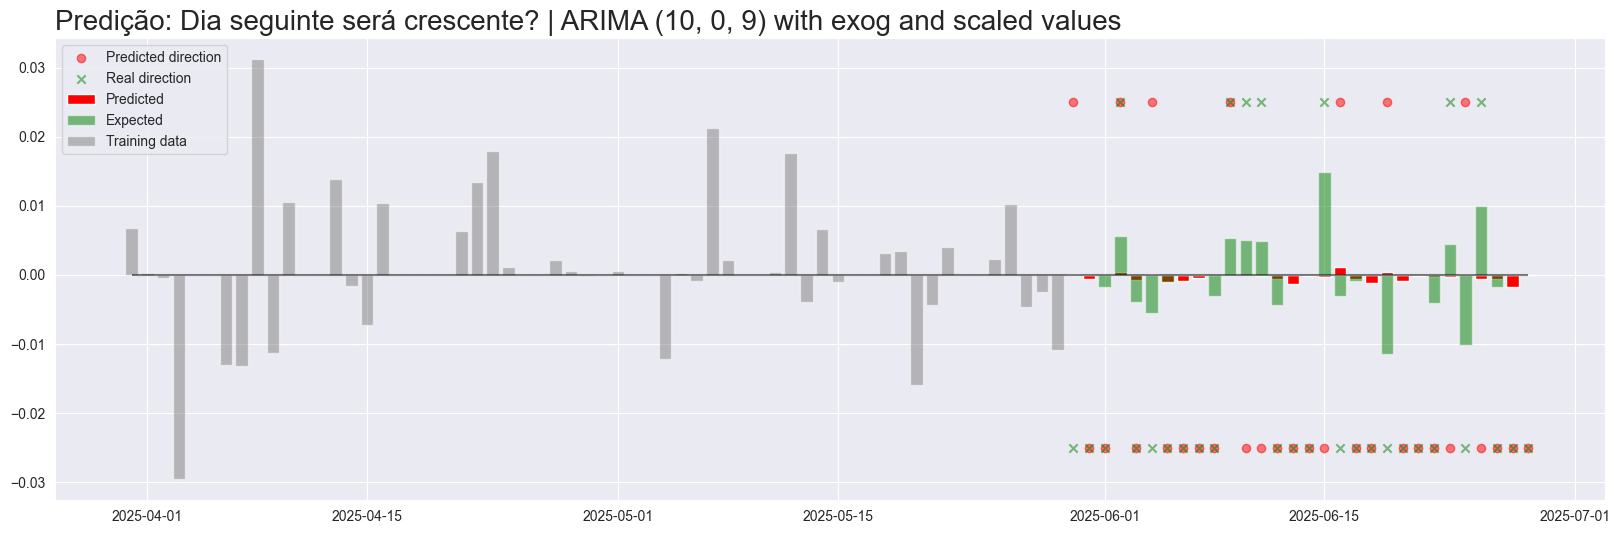

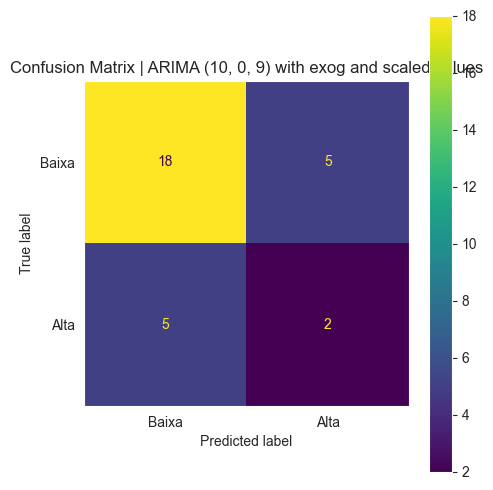

In [327]:
exog_cols = ['abertura', 'maxima', 'minima', 'dia_semana']

model = ARIMA(
    endog = y_cont_train,
    exog = X_cont_train_scaled[exog_cols],
    order = (10, 0, 9)
).fit()

y_pred = model.forecast(
    steps = n_predictions,
    exog = X_cont_test_scaled[exog_cols]
)

fig1, fig2 = plot_and_get_metrics(
    y_pred,
    y_cont_test,
    y_cont_train,
    model = 'ARIMA (10, 0, 9) with exog and scaled values'
)

export_fig(
    fig1,
    'pred_scaled_arima1009',
    True
)

export_fig(
    fig2,
    'pred_scaled_arima1009_cm'
)

In [ ]:
exog_cols = ['abertura', 'maxima', 'minima', 'dia_semana']

model = ARIMA(
    endog = y_cont_train,
    exog = X_cont_train_scaled[exog_cols],
    order = (60, 0, 2)
).fit()

y_pred = model.forecast(
    steps = n_predictions,
    exog = X_cont_test_scaled[exog_cols]
)

fig1, fig2 = plot_and_get_metrics(
    y_pred,
    y_cont_test,
    y_cont_train,
    model = 'ARIMA (60, 0, 2) with exog and scaled values'
)

export_fig(
    fig1,
    'pred_scaled_arima6002',
    True
)

export_fig(
    fig2,
    'pred_scaled_arima6002_cm'
)

d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\_FIAP\02.Challenge 2\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


#### Search & Validation

##### Cross-Validation

In [ ]:
def validate_arima(
        x,
        y,
        exog = None,
        p : int = 2,
        d : int = 0,
        q : int = 2,
        console = False
):
    '''Runs the built model through 10 Time Series folds. Returns the mean accuracy of all the folds.'''
    scores = []
    fold = 0
    for train_idx, test_idx in kft.split(x, y):
        fold += 1
        
        x_train = x.iloc[train_idx]
        x_test = x.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        if console:
            print(f'FOLD {fold} | Training on {len(y_train)} | Testing on {len(y_test)}')
        
        ypred = []
        y_true = [] 

        if exog == None:
            model = ARIMA(
                endog = y_train,
                order = (p, d, q)
            ).fit()

            y_pred = model.forecast(
                steps = len(y_test)
            )
        else:
            model = ARIMA(
                endog = y_train,
                exog = x_train[exog],
                order = (p, d, q)
            ).fit()

            y_pred = model.forecast(
                steps = len(y_test),
                exog = x_test[exog]
            )
        
        df_pred, df_true = make_y_dfs(y_pred = y_pred, 
                                      y_true = y_test)

        acc, prec, rec = get_class_metrics(
            df_pred = df_pred,
            df_true = df_true)   

        if console:
            print(f'ACC = {acc:.4f} | PREC = {prec:.4f} | REC = {rec:.4f}')
            print('='*30)
            print()
        scores.append([acc, prec, rec])
    accs = [i[0] for i in scores]
    acc_max = max(accs)
    
    acc_mean = sum(accs) / len(accs)
    if console:
        print(f'Accuracy mean: {acc_mean} (max: {acc_max})')

    return acc_mean, acc_max


In [329]:
validate_arima(
    x = df_cont[x_parameters],
    y = df_cont['var_amanha'],
    exog =  ['abertura', 'maxima', 'minima', 'dia_semana'],
    console = True
)

FOLD 1 | Training on 5329 | Testing on 30
ACC = 0.5667 | PREC = 0.0000 | REC = 0.0000

FOLD 2 | Training on 5359 | Testing on 30
ACC = 0.7333 | PREC = 0.5000 | REC = 0.2500

FOLD 3 | Training on 5389 | Testing on 30
ACC = 0.6000 | PREC = 0.2857 | REC = 0.2222

FOLD 4 | Training on 5419 | Testing on 30
ACC = 0.6000 | PREC = 0.3750 | REC = 0.3000

FOLD 5 | Training on 5449 | Testing on 30
ACC = 0.5667 | PREC = 0.3750 | REC = 0.2727

FOLD 6 | Training on 5479 | Testing on 30
ACC = 0.7333 | PREC = 0.6667 | REC = 0.4000

FOLD 7 | Training on 5509 | Testing on 30
ACC = 0.5667 | PREC = 0.5000 | REC = 0.2308

FOLD 8 | Training on 5539 | Testing on 30
ACC = 0.6333 | PREC = 0.5556 | REC = 0.4167

FOLD 9 | Training on 5569 | Testing on 30
ACC = 0.6333 | PREC = 0.6000 | REC = 0.2500

FOLD 10 | Training on 5599 | Testing on 30
ACC = 0.8000 | PREC = 0.5714 | REC = 0.5714

Accuracy mean: 0.6433333333333333


0.6433333333333333

In [330]:
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# exog_cols = ['ultimo', 'abertura', 'maxima', 'minima']#, 'volume']#, 'var']

# exog_cols = ['ultimo', 'abertura', 'maxima', 'minima', 'var', 'const']#, 'volume', 'dia_util', 'dia_util_anterior']

# model = SARIMAX(
#     endog = y_cont_train,
#     exog = X_cont_train[exog_cols],
#     order = (2, 0, 2),
#     seasonal_order = (7, 0, 7, 7)
# ).fit()

# y_pred = model.forecast(
#     steps = n_predictions,
#     exog = X_cont_test[exog_cols]
# )

# plot_and_get_metrics(
#     y_pred,
#     y_cont_test,
#     y_cont_train,
#     model = 'SARIMAX (2, 0, 2) with exog'
# )

##### Exog search

In [331]:
from itertools import combinations
import warnings

def grid_arima_exog(
    x_train : pd.DataFrame,
    y_train : pd.Series,
    x_test : pd.DataFrame,
    y_test : pd.Series, 
    exog_candidates : list,
    max_exog : int = 3
):
    '''
    Searches for the exog configuration with the best accuracy.
    '''
    options_amount = len(exog_candidates)

    options = list(combinations(exog_candidates, r = min(options_amount, max_exog)))

    scores = []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for exog in options:
            try:
                model = ARIMA(
                    endog = y_train,
                    exog = x_train.loc[:,exog],
                    order = (2, 0, 2)
                ).fit()

                y_pred = model.forecast(
                    steps = n_predictions,
                    exog = x_test.loc[:,exog]
                )

                df_pred, df_true = make_y_dfs(y_pred=y_pred, y_true=y_test)
                acc, prec, rec = get_class_metrics(df_pred = df_pred, df_true = df_true)

                scores.append([exog, acc, [acc, prec, rec]])
            except Exception as e:
                print(f'Failed {exog}, moving on | {e}')
                continue
    
    scores.sort(key = lambda x: x[1], reverse=True)

    return scores

In [ ]:
def grid_arima_exog_validated(
    x : pd.DataFrame,
    y : pd.Series,
    exog_candidates : list,
    max_exog : int = 3,
    p = 2,
    d = 0,
    q = 2
):
    '''
    Searches for the exog configuration with the best average accuracy across 10 folds.
    '''
    options_amount = len(exog_candidates)

    exog_options = list(combinations(exog_candidates, r = min(options_amount, max_exog)))
    scores = []

    count = 0

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for exog in exog_options:
            count += 1
            
            if count % 40 == 0:
                print(f'{count} / {len(exog_options)}')
            try:
                acc_mean, acc_max = validate_arima(
                    x,
                    y,
                    exog = [e for e in exog]
                )

                scores.append([exog, acc_mean, acc_max])
            except Exception as e:
                print(f'Failed {exog}, moving on | {e}')
                continue
    
    scores.sort(key = lambda x: x[1], reverse=True)

    return scores

In [333]:
# scores = grid_arima_exog_validated(
#     x = X_cont,
#     y = y_cont,
#     exog_candidates = x_parameters,
#     max_exog = 6
# )

# import json
# with open('scores/arima_exog_6_validated.csv', 'w') as file:
#     json.dump(scores, file)

# # RESULTS HAVE BEEN EXPORTED
# scores

In [334]:
# scores = grid_arima_exog_validated(
#     x = X_cont,
#     y = y_cont,
#     exog_candidates = x_parameters,
#     max_exog = 5
# )

# import json
# with open('scores/arima_exog_5_validated.csv', 'w') as file:
#     json.dump(scores, file)

# # RESULTS HAVE BEEN EXPORTED
# scores

In [335]:
# scores = grid_arima_exog_validated(
#     x = X_cont,
#     y = y_cont,
#     exog_candidates = x_parameters,
#     max_exog = 4
# )

# import json
# with open('scores/arima_exog_4_validated.csv', 'w') as file:
#     json.dump(scores, file)

# # RESULTS HAVE BEEN EXPORTED
# scores

In [336]:
# scores = grid_arima_exog_validated(
#     x = X_cont,
#     y = y_cont,
#     exog_candidates = x_parameters,
#     max_exog = 3
# )

# import json
# with open('scores/arima_exog_3_validated.csv', 'w') as file:
#     json.dump(scores, file)

# # RESULTS HAVE BEEN EXPORTED
# scores

In [337]:
# # scores = grid_arima_exog(
# #     X_cont_train,
# #     y_cont_train,
# #     X_cont_test,
# #     y_cont_test,
# #     exog_candidates = x_parameters,
# #     max_exog = 3
# # )

# import json
# with open('scores/arima_exog_3.csv', 'w') as file:
#     json.dump(scores, file)
# scores

# RESULTS HAVE BEEN EXPORTED

In [338]:
# scores = grid_arima_exog(
#     X_cont_train,
#     y_cont_train,
#     X_cont_test,
#     y_cont_test,
#     exog_candidates = x_parameters,
#     max_exog = 4
# )

# import json
# with open('scores/arima_exog_4.csv', 'w') as file:
#     json.dump(scores, file)

# scores

# RESULTS HAVE BEEN EXPORTED

##### Order search

In [ ]:
from itertools import product

def grid_arima(
        x : pd.DataFrame,
        y : pd.Series, 
        exog = None,
        pmin : int = 0, pmax : int = 3, 
        dmin : int = 0, dmax : int = 1, 
        qmin : int = 0, qmax : int = 3):
    
    p = range(pmin, pmax+1)
    d = range(dmin, dmax+1)
    q = range(qmin, qmax+1)

    pqd = list(product(p, d, q))

    scores = []
    
    count = 0

    print(f'Running {len(pqd)} tests')

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for order in pqd:
            count += 1

            if count % 40 == 0:
                print(f'{count} / {len(pqd)}')
            try:
                acc_mean = -1
                if exog == None:
                    acc_mean, acc_max = validate_arima(
                        x,
                        y,
                        p = order[0],
                        q = order[1],
                        d = order[2],
                    )    
                else:
                    acc_mean, acc_max = validate_arima(
                        x,
                        y,
                        p = order[0],
                        q = order[1],
                        d = order[2],
                        exog = [e for e in exog]
                    )
                scores.append([order, acc_mean, acc_max])
            except Exception as e:
                print(f'Failed {order}, moving on | {e}')
                continue

    scores.sort(key = lambda x: x[1], reverse = True)

    return scores

In [340]:
# scores = grid_arima(
#     x = X_cont,
#     y = y_cont,
#     exog = None,
#     pmin = 5,
#     pmax = 14,
#     dmin = 0,
#     dmax = 0,
#     qmin = 4,
#     qmax = 14
# )
# import json
# with open('scores/arima_pqd_(514_00_414).csv', 'w') as file:
#     json.dump(scores, file)

# # RESULTS HAVE BEEN EXPORTED
# scores

In [341]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def grid_sarimax(
        x_train : pd.DataFrame,
        y_train,
        x_test,
        y_test, 
        p : int = 6,
        d : int = 3,
        q : int = 0,
        Pmin : int = 0, Pmax : int = 3, 
        Dmin : int = 0, Dmax : int = 1, 
        Qmin : int = 0, Qmax : int = 3,
        smin : int = 2, smax : int = 10):
    P = range(Pmin, Pmax+1)
    D = range(Dmin, Dmax+1)
    Q = range(Qmin, Qmax+1)
    s = range(smin, smax)

    pqd = list(product(P, D, Q, s))

    scores = []

    i = 0

    print(f'Running {len(pqd)} tests')
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for order in pqd:
            i+=1
            if i % 5 == 0:
                print(f'{i} / {len(pqd)}')
            # print(f'Testing {order}')
            try:
                model = SARIMAX(
                    endog = y_train,
                    exog = x_train,
                    order = (p, d, q),
                    seasonal_order = order
                ).fit()

                y_hat = model.forecast(
                    n_predictions,
                    exog = x_test
                    )
                y_pred = pd.Series([1 if y_hat.iloc[i] > 0 else 0 for i in range(len(y_hat))])
                scores.append(
                    (order, 
                    accuracy_score(y_true = y_test, y_pred = y_pred))
                    )
                                
            except Exception as e:
                print(f'Failed {order}, moving on | {e}')
                continue
    
    scores.sort(key = lambda x: x[1])

    return scores

In [342]:
# sarima_scores = grid_sarimax(
#     x_train = X_train,
#     y_train = y_train,
#     x_test = X_test,
#     y_test = y_test,
#     Pmin = 6,
#     Pmax = 10,
#     Dmin = 2,
#     Dmax = 3,
#     Qmin = 2,
#     Qmax = 5,
#     smin = 6,
#     smax = 8
# )
# sarima_scores

# (6, 2, 2, 7)

### Prophet

In [414]:
from prophet import Prophet
df_prophet = y_cont_train.reset_index()
df_prophet.columns  = ['ds', 'y']

df_prophet.head(3)

,ds,y
0,2010-01-30,0.0000
1,2010-01-31,0.0179
2,2010-02-01,0.0089


In [415]:
model = Prophet()
model.fit(df_prophet)

future = model.make_future_dataframe(periods = n_predictions)

16:56:26 - cmdstanpy - INFO - Chain [1] start processing
16:56:26 - cmdstanpy - INFO - Chain [1] done processing


In [416]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
5624,2025-06-24,0.000177,-0.016017,0.015654
5625,2025-06-25,-0.000089,-0.015321,0.015105
5626,2025-06-26,-0.000453,-0.016614,0.015344
5627,2025-06-27,-0.000170,-0.015156,0.014829
5628,2025-06-28,-0.000067,-0.017075,0.015420


In [417]:
mask = forecast['ds'] > (y_cont_test.index[0] - datetime.timedelta(days=1))
y_pred = forecast[mask]['yhat']
y_pred.index = y_cont_test.index

ACC = 0.7333 | PREC = 0.4444 | REC = 0.5714


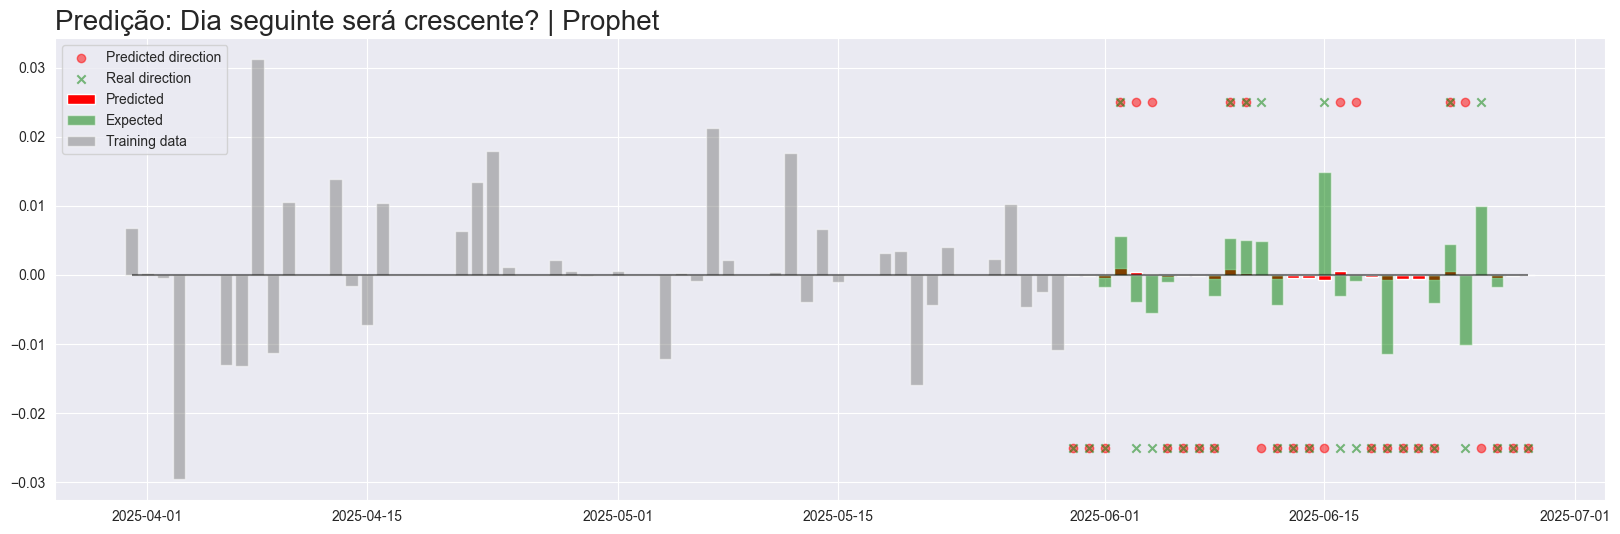

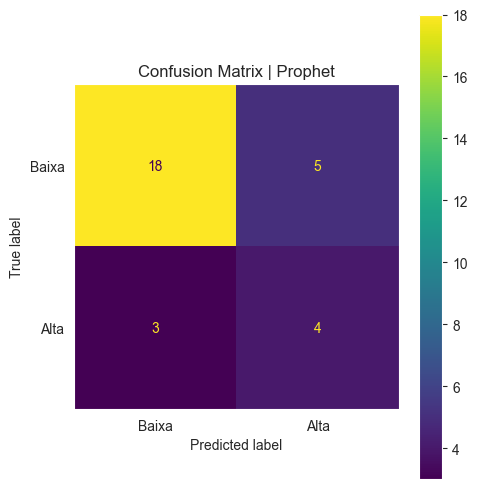

In [418]:
fig1, fig2 = plot_and_get_metrics(
    y_pred = y_pred,
    y_true = y_cont_test,
    y_train = y_cont_train,
    model = 'Prophet'
)


export_fig(
    fig1,
    'pred_prophet',
    True
)

export_fig(
    fig2,
    'pred_prophet_cm'
)

#### Cross-Validation

In [428]:
def validate_prophet(
        y : pd.DataFrame,
        console = False
):
    '''Runs the built model through 10 Time Series folds. Returns the mean accuracy of all the folds.'''
    scores = []
    fold = 0
    for train_idx, test_idx in kft.split(y, y):
        fold += 1

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        y_test = y_test.set_index('ds')

        model = Prophet()
        model.fit(y_train)

        future = model.make_future_dataframe(
            periods = len(y_test)
            )
        
        forecast = model.predict(future)

        mask = forecast['ds'] > (y_test.index[0] - datetime.timedelta(days=1))
        y_pred = forecast[mask]['yhat']
        y_pred.index = y_test.index

        if console:
            print(f'FOLD {fold} | Training on {len(y_train)} | Testing on {len(y_test)}')
        
        df_pred, df_true = make_y_dfs(y_pred = y_pred, 
                                      y_true = y_test['y'])

        acc, prec, rec = get_class_metrics(
            df_pred = df_pred,
            df_true = df_true)   

        if console:
            print(f'ACC = {acc:.4f} | PREC = {prec:.4f} | REC = {rec:.4f}')
            print('='*30)
            print()
        scores.append([acc, prec, rec])
    accs = [i[0] for i in scores]
    acc_mean = sum(accs) / len(accs)
    if console:
        print(f'Accuracy mean: {acc_mean}')

    return acc_mean


In [429]:
validate_prophet(
    y = df_prophet,
    console = True
)

16:59:27 - cmdstanpy - INFO - Chain [1] start processing
16:59:27 - cmdstanpy - INFO - Chain [1] done processing


FOLD 1 | Training on 5299 | Testing on 30
ACC = 0.4667 | PREC = 0.4444 | REC = 0.5714



16:59:28 - cmdstanpy - INFO - Chain [1] start processing
16:59:28 - cmdstanpy - INFO - Chain [1] done processing


FOLD 2 | Training on 5329 | Testing on 30
ACC = 0.6000 | PREC = 0.4375 | REC = 0.7000



16:59:29 - cmdstanpy - INFO - Chain [1] start processing
16:59:29 - cmdstanpy - INFO - Chain [1] done processing


FOLD 3 | Training on 5359 | Testing on 30
ACC = 0.4333 | PREC = 0.3043 | REC = 0.8750



16:59:30 - cmdstanpy - INFO - Chain [1] start processing
16:59:31 - cmdstanpy - INFO - Chain [1] done processing


FOLD 4 | Training on 5389 | Testing on 30
ACC = 0.5667 | PREC = 0.3571 | REC = 0.5556



16:59:31 - cmdstanpy - INFO - Chain [1] start processing
16:59:32 - cmdstanpy - INFO - Chain [1] done processing


FOLD 5 | Training on 5419 | Testing on 30
ACC = 0.5667 | PREC = 0.4211 | REC = 0.8000



16:59:33 - cmdstanpy - INFO - Chain [1] start processing
16:59:33 - cmdstanpy - INFO - Chain [1] done processing


FOLD 6 | Training on 5449 | Testing on 30
ACC = 0.4333 | PREC = 0.3333 | REC = 0.5455



16:59:34 - cmdstanpy - INFO - Chain [1] start processing
16:59:34 - cmdstanpy - INFO - Chain [1] done processing


FOLD 7 | Training on 5479 | Testing on 30
ACC = 0.6000 | PREC = 0.4500 | REC = 0.9000



16:59:35 - cmdstanpy - INFO - Chain [1] start processing
16:59:35 - cmdstanpy - INFO - Chain [1] done processing


FOLD 8 | Training on 5509 | Testing on 30
ACC = 0.5667 | PREC = 0.5000 | REC = 0.3846



16:59:36 - cmdstanpy - INFO - Chain [1] start processing
16:59:37 - cmdstanpy - INFO - Chain [1] done processing


FOLD 9 | Training on 5539 | Testing on 30
ACC = 0.5000 | PREC = 0.4211 | REC = 0.6667



16:59:38 - cmdstanpy - INFO - Chain [1] start processing
16:59:38 - cmdstanpy - INFO - Chain [1] done processing


FOLD 10 | Training on 5569 | Testing on 30
ACC = 0.7000 | PREC = 0.8000 | REC = 0.3333

Accuracy mean: 0.5433333333333333


0.5433333333333333